In [44]:
import numpy as np
import pandas as pd
import scipy
from sympy.abc import s,t,w,x,y
import sympy as sp
from control import matlab as mt
import control as ctrl
import matplotlib.pyplot as plt
from warnings import filterwarnings

filterwarnings("ignore")

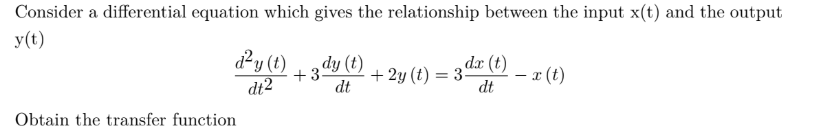

In [12]:
x=sp.Function("x")(t)
y=sp.Function("y")(t)

In [13]:
output=sp.diff(y,t,2)+3*sp.diff(y,t)+2*y
input=3*sp.diff(x,t)-x

In [14]:
input

-x(t) + 3*Derivative(x(t), t)

In [15]:
output

2*y(t) + 3*Derivative(y(t), t) + Derivative(y(t), (t, 2))

In [16]:
output_s=sp.integrals.laplace_transform(output,t,s,noconds=True,legacy_matrix=False )
input_s=sp.integrals.laplace_transform(input,t,s,noconds=True)

In [17]:
output_s

s**2*LaplaceTransform(y(t), t, s) + 3*s*LaplaceTransform(y(t), t, s) - s*y(0) + 2*LaplaceTransform(y(t), t, s) - 3*y(0) - Subs(Derivative(y(t), t), t, 0)

In [18]:
input_s

3*s*LaplaceTransform(x(t), t, s) - LaplaceTransform(x(t), t, s) - 3*x(0)

In [19]:
#Transfer Function
H=(output_s/input_s)**-1
H

(3*s*LaplaceTransform(x(t), t, s) - LaplaceTransform(x(t), t, s) - 3*x(0))/(s**2*LaplaceTransform(y(t), t, s) + 3*s*LaplaceTransform(y(t), t, s) - s*y(0) + 2*LaplaceTransform(y(t), t, s) - 3*y(0) - Subs(Derivative(y(t), t), t, 0))

# Poles and Zeros of a Transfer Function

Determine the poles and zeros of the following Transfer function and obtain the transfer function

$G(s)=\frac{3(s+3)(s+1.5)^3}{(s+5)(s+7)^2}$

In [31]:
num=np.convolve([3,9],np.convolve([1,1.5],[1,1.5]))
den=np.convolve([1,5],np.convolve([1,7],[1,7]))

sys=ctrl.TransferFunction(num,den)
sys

TransferFunction(
array([ 3.  , 18.  , 33.75, 20.25]),
array([  1,  19, 119, 245]),
outputs=1, inputs=1)

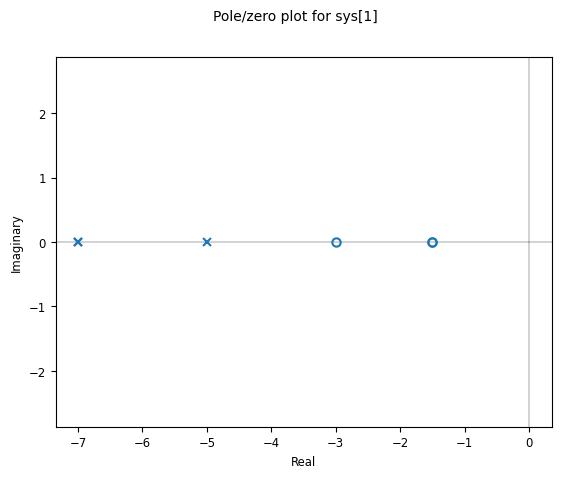

In [36]:
ctrl.pole_zero_plot(sys)
plt.show()

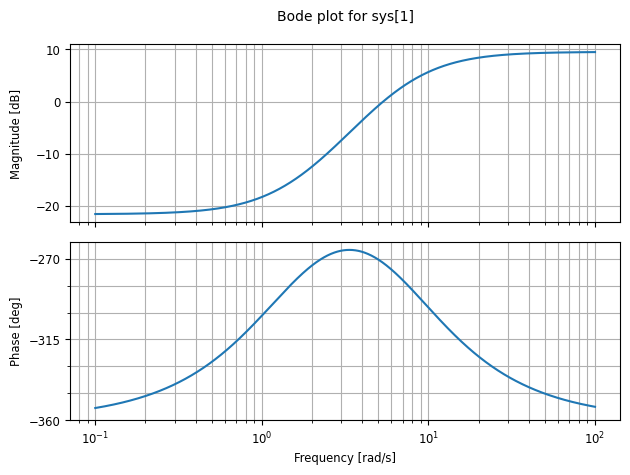

In [45]:
response_data=mt.bode(sys)
plt.show()

In [46]:
ctrl.tfdata(sys)

([[array([ 3.  , 18.  , 33.75, 20.25])]], [[array([  1,  19, 119, 245])]])

In [51]:
ctrl.tf2io(sys)

StateSpace(
array([[ -19., -119., -245.],
       [   1.,    0.,    0.],
       [   0.,    1.,    0.]]),
array([[1.],
       [0.],
       [0.]]),
array([[ -39.  , -323.25, -714.75]]),
array([[3.]]),
states=3, outputs=1, inputs=1)

In [52]:
ctrl.tf2ss(sys)


StateSpace(
array([[ -19., -119., -245.],
       [   1.,    0.,    0.],
       [   0.,    1.,    0.]]),
array([[1.],
       [0.],
       [0.]]),
array([[ -39.  , -323.25, -714.75]]),
array([[3.]]),
states=3, outputs=1, inputs=1)

In [53]:
mt.poles(sys)

array([-7.00000038+0.j, -6.99999962+0.j, -5.        +0.j])

In [54]:
mt.zeros(sys)

array([-3. +0.00000000e+00j, -1.5+2.56242853e-08j, -1.5-2.56242853e-08j])

In [55]:
mt.dcgain(sys)

np.float64(0.0826530612244898)